In [1]:
import numpy as np
import pandas as pd
from binance.client import Client as bnb_client
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import statsmodels.api as sm
from skopt import gp_minimize
from skopt.space import Integer, Real
from skopt.utils import use_named_args
import warnings
warnings.filterwarnings('ignore')
 
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# 1. Data Collection

In [2]:
client = bnb_client(tld='US')
 
def get_binance_px(symbol, freq, start_ts, end_ts):
    data = client.get_historical_klines(symbol, freq, start_ts, end_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
               'num_trades','taker_base_volume','taker_quote_volume','ignore']
    data = pd.DataFrame(data, columns=columns)
    data['open_time'] = data['open_time'].map(
        lambda x: datetime.fromtimestamp(x/1000, timezone.utc).replace(tzinfo=None))
    data['close_time'] = data['close_time'].map(
        lambda x: datetime.fromtimestamp(x/1000, timezone.utc).replace(tzinfo=None))
    return data
 
freq = '12h'
 
exchange_info = client.get_exchange_info()
symbols = [i['symbol'] for i in exchange_info['symbols']]
univ = [symbol for symbol in symbols if symbol.endswith('USDT')]

In [3]:
train_start = '2021-06-01'
train_end   = '2024-12-31'
test_start  = '2025-01-01'
test_end    = '2026-06-30'
 
px = {}
volume = {}
px_test = {}
volume_test = {}
 
for x in univ:
    data = get_binance_px(x, freq, train_start, train_end)
    px[x] = data.set_index('open_time')['close']
    volume[x] = data.set_index('open_time')['volume']
 
    test_data = get_binance_px(x, freq, test_start, test_end)
    px_test[x] = test_data.set_index('open_time')['close']
    volume_test[x] = test_data.set_index('open_time')['volume']
 
px = pd.DataFrame(px).astype(float)
px = px.reindex(pd.date_range(px.index[0], px.index[-1], freq=freq))
volume = pd.DataFrame(volume).astype(float)
volume = volume.reindex(px.index)
 
px_test = pd.DataFrame(px_test).astype(float)
px_test = px_test.reindex(pd.date_range(px_test.index[0], px_test.index[-1], freq=freq))
volume_test = pd.DataFrame(volume_test).astype(float)
volume_test = volume_test.reindex(px_test.index)
 
print(f'Universe: {len(univ)} coins | Train: {px.shape} | Test: {px_test.shape}')

Universe: 231 coins | Train: (2619, 231) | Test: (898, 231)


In [4]:
# Compute returns & BTC filter
ret = px.pct_change().fillna(0)
 
btc_px  = px['BTCUSDT']
btc_ret = btc_px.pct_change()
ret = ret.drop(columns=['BTCUSDT'])
 
# ADV filter: only trade coins with reasonable liquidity (top 80% by median volume)
adv = volume.drop(columns=['BTCUSDT'], errors='ignore').median()
liquid_coins = adv[adv > adv.quantile(0.20)].index
ret = ret[ret.columns.intersection(liquid_coins)]
print(f'Liquid universe: {len(ret.columns)} coins (dropped {len(univ)-1-len(ret.columns)} illiquid)')

Liquid universe: 139 coins (dropped 91 illiquid)


# 2. Performance Evaluation

In [5]:
FREQ = 365 * 2   # 12h bars per year
 
def get_stats(ret_series, freq=FREQ):
    stats = {}
    stats['Sharpe']  = ret_series.mean() / ret_series.std() * np.sqrt(freq)
    stats['Ann Ret'] = ret_series.mean() * freq
    stats['Ann Vol'] = ret_series.std() * np.sqrt(freq)
    return pd.Series(stats)
 
def get_stats_multi(ret_df, freq=FREQ):
    stats = {}
    stats['Sharpe']  = ret_df.mean() / ret_df.std() * np.sqrt(freq)
    stats['Ann Ret'] = ret_df.mean() * freq
    stats['Ann Vol'] = ret_df.std() * np.sqrt(freq)
    return pd.DataFrame(stats)
 
def max_drawdown(returns):
    equity = (1 + returns).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    return drawdown.min()
 
def rolling_sharpe(returns, window=365):
    """Rolling annualized Sharpe for diagnostics."""
    rm = returns.rolling(window).mean()
    rs = returns.rolling(window).std()
    return (rm / rs * np.sqrt(FREQ)).dropna()
 
def full_report(returns, name='Strategy', freq=FREQ):
    """Print a full performance report."""
    stats = {}
    stats['Sharpe']       = returns.mean() / returns.std() * np.sqrt(freq)
    stats['Ann Return']   = returns.mean() * freq
    stats['Ann Vol']      = returns.std() * np.sqrt(freq)
    stats['Max Drawdown'] = max_drawdown(returns)
    stats['Calmar']       = stats['Ann Return'] / abs(stats['Max Drawdown'])
    stats['Skewness']     = returns.skew()
    stats['Kurtosis']     = returns.kurtosis()
    stats['Hit Rate']     = (returns > 0).mean()
    s = pd.Series(stats, name=name).round(3)
    print(f'\n--- {name} ---')
    print(s.to_string())
    return s

# 3. Mean Reversion

In [6]:
def mean_reversion_v3(px_df, ret_df, btc_px_series,
                       lookbacks=[1, 2, 4, 8],
                       pctile=92,
                       pctile_window=180,
                       hold_periods=3,
                       hold=None,
                       cost_bps=20,
                       btc_sma_short=20,
                       btc_sma_long=100,
                       max_pos_per_coin=0.10):
    
    cost = cost_bps / 10000.0
    if hold is not None:
        hold_periods = hold
    
    # BTC regime filter
    btc_sma_s = btc_px_series.rolling(btc_sma_short).mean()
    btc_sma_l = btc_px_series.rolling(btc_sma_long).mean()
    # Fully shut off in bear regime (short SMA < long SMA)
    btc_regime = np.where(btc_sma_s > btc_sma_l, 1.0, 0.0)
    btc_regime = pd.Series(btc_regime, index=btc_px_series.index)
    
    # Multi-lookback ensemble with decaying positions
    # Instead of on/off, each signal decays over hold_periods
    cols = ret_df.columns
    pos_accumulated = pd.DataFrame(0.0, index=px_df.index, columns=cols)
    
    for lb in lookbacks:
        pct_ret = px_df[cols].pct_change(lb)
        
        # Adaptive threshold: rolling percentile of abs returns
        abs_ret = pct_ret.abs()
        threshold = abs_ret.rolling(pctile_window, min_periods=30).quantile(pctile / 100.0)
        
        long_sig  = (pct_ret < -threshold) * 1.0
        short_sig = (pct_ret >  threshold) * -1.0
        raw_sig = long_sig + short_sig
        
        # Decay: hold signal for hold_periods with linearly decreasing weight
        for h in range(hold_periods):
            weight = (hold_periods - h) / hold_periods
            pos_accumulated += raw_sig.shift(h).fillna(0) * weight
    
    # Average across lookbacks and hold periods
    n_signals = len(lookbacks) * hold_periods
    port = pos_accumulated / n_signals
    
    # Lag by 1 (execution delay)
    pos = port.shift(1).fillna(0.0)
    
    # Per-coin position cap
    pos = pos.clip(-max_pos_per_coin * pos.abs().sum(axis=1).replace(0,1).values[:,None],
                    max_pos_per_coin * pos.abs().sum(axis=1).replace(0,1).values[:,None])
    
    # Normalize to unit gross exposure
    gross = pos.abs().sum(axis=1).replace(0, np.nan)
    scaled_pos = pos.div(gross, axis=0).fillna(0.0)
    
    # Gross returns
    mr_ret = (scaled_pos * ret_df).sum(axis=1).fillna(0.0)
    
    # Transaction costs on NORMALIZED positions (this is the fix!)
    turnover = (scaled_pos - scaled_pos.shift(1).fillna(0)).abs().sum(axis=1)
    mr_net = mr_ret - turnover * cost
    
    # BTC vol scaling — INVERTED: trade more in calm markets, less in volatile
    btc_vol = btc_px_series.pct_change().rolling(48).std()
    btc_vol_ratio = (btc_vol / btc_vol.rolling(200).median())
    # Invert: low vol → scale up, high vol → scale down (capped)
    mr_scale = (1.0 / btc_vol_ratio).clip(0.5, 1.5).shift(1).fillna(1.0)
    mr_net_scaled = mr_net * mr_scale
    
    # Apply BTC regime filter
    mr_net_scaled = mr_net_scaled * btc_regime.reindex(mr_net_scaled.index, method='ffill').fillna(1.0)
    
    return mr_net_scaled.fillna(0.0)
 
 
# Run with defaults
mr_ret_opt = mean_reversion_v3(px, ret, btc_px)
full_report(mr_ret_opt, 'Mean Reversion v3')
 
# Grid search over key params to find a good combo
print('\nGrid searching over pctile and lookback combos...')
best_sr, best_params = -99, {}
results_mr = []
 
for pctile in [88, 90, 92, 94, 96]:
    for hold in [2, 3, 4, 5]:
        for lookbacks in [[1,2,4,8], [1,3,6,12], [2,4,8,16], [1,2,3,4,6,8]]:
            mr_test = mean_reversion_v3(px, ret, btc_px,
                                         lookbacks=lookbacks,
                                         pctile=pctile,
                                         hold_periods=hold)
            sr = mr_test.mean() / mr_test.std() * np.sqrt(FREQ)
            dd = max_drawdown(mr_test)
            results_mr.append({'pctile': pctile, 'hold': hold,
                               'lookbacks': str(lookbacks),
                               'sharpe': round(sr,3), 'dd': round(dd,3)})
            if sr > best_sr:
                best_sr = sr
                best_params = {'pctile': pctile, 'hold_periods': hold, 'lookbacks': lookbacks}
 
results_mr_df = pd.DataFrame(results_mr)
print(f'\nBest MR params: {best_params}  (Sharpe={best_sr:.3f})')
print('\nTop 10:')
print(results_mr_df.sort_values('sharpe', ascending=False).head(10).to_string(index=False))
 
# Rerun with best params
mr_ret_opt = mean_reversion_v3(px, ret, btc_px, **best_params)
full_report(mr_ret_opt, 'Mean Reversion v3 (Best Params)')


--- Mean Reversion v3 ---
Sharpe           1.399
Ann Return       0.813
Ann Vol          0.581
Max Drawdown    -0.607
Calmar           1.339
Skewness        -0.394
Kurtosis        12.199
Hit Rate         0.282

Grid searching over pctile and lookback combos...

Best MR params: {'pctile': 94, 'hold_periods': 2, 'lookbacks': [1, 3, 6, 12]}  (Sharpe=1.648)

Top 10:
 pctile  hold          lookbacks  sharpe     dd
     94     2      [1, 3, 6, 12]   1.648 -0.718
     94     2 [1, 2, 3, 4, 6, 8]   1.617 -0.746
     92     2       [1, 2, 4, 8]   1.593 -0.731
     92     2 [1, 2, 3, 4, 6, 8]   1.564 -0.736
     92     2      [1, 3, 6, 12]   1.560 -0.739
     94     2       [1, 2, 4, 8]   1.556 -0.797
     94     3 [1, 2, 3, 4, 6, 8]   1.537 -0.545
     94     3       [1, 2, 4, 8]   1.479 -0.620
     94     3      [1, 3, 6, 12]   1.450 -0.586
     96     2      [1, 3, 6, 12]   1.435 -0.838

--- Mean Reversion v3 (Best Params) ---
Sharpe           1.648
Ann Return       1.136
Ann Vol          0.

Sharpe           1.648
Ann Return       1.136
Ann Vol          0.689
Max Drawdown    -0.718
Calmar           1.583
Skewness        -0.645
Kurtosis        13.296
Hit Rate         0.291
Name: Mean Reversion v3 (Best Params), dtype: float64


--- Mean Reversion (Original) ---
Sharpe           1.759
Ann Return       3.198
Ann Vol          1.818
Max Drawdown    -0.997
Calmar           3.209
Skewness        -0.124
Kurtosis        15.506
Hit Rate         0.362


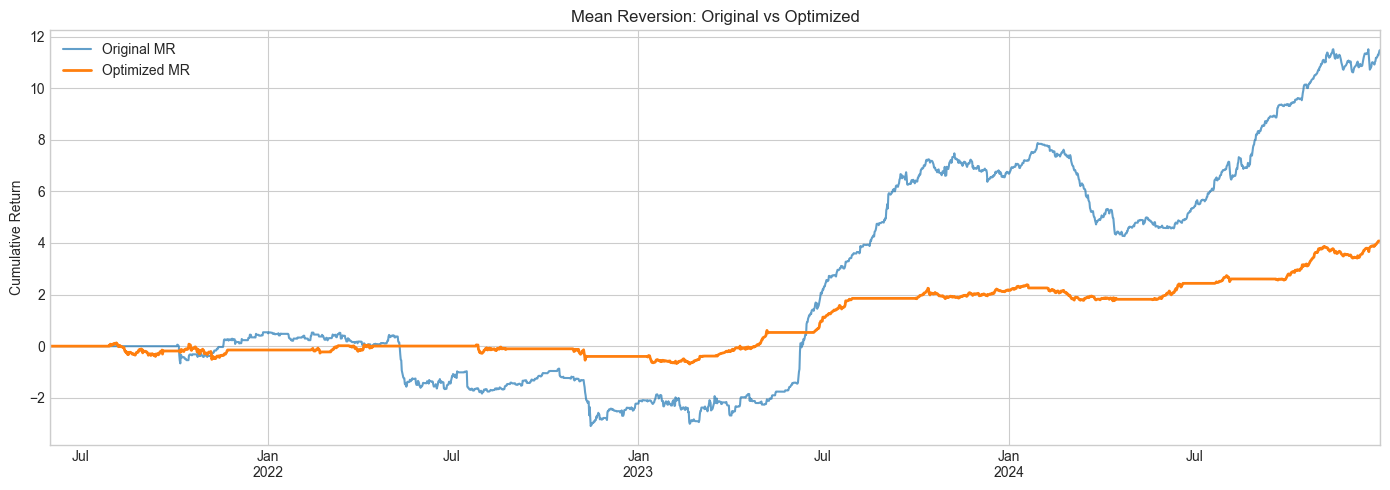

In [7]:
# Compare: original mean reversion (for reference)
lookback = 1
x = 0.11
long = (px[ret.columns].pct_change(lookback) < -x) * 1.0
short = (px[ret.columns].pct_change(lookback) > x) * -1.0
port_orig = long + short
pos_orig = port_orig.shift().fillna(0.0)
gross_orig = pos_orig.abs().sum(1).replace(0, np.nan)
scaled_pos_orig = pos_orig.div(gross_orig, axis=0).fillna(0.0)
rev_ret_orig = (scaled_pos_orig * ret).sum(1).fillna(0.0)
to_orig = (port_orig.fillna(0) - port_orig.shift().fillna(0)).abs().sum(1)
mr_net_orig = rev_ret_orig - to_orig * 0.002
btc_vol = btc_px.pct_change().rolling(48).std()
mr_scale = (btc_vol / btc_vol.rolling(200).median()).clip(0.5, 1.5).shift(1)
mr_net_orig_scaled = mr_net_orig * mr_scale
 
full_report(mr_net_orig_scaled.fillna(0), 'Mean Reversion (Original)')
 
# Visual comparison
fig, ax = plt.subplots(figsize=(14, 5))
mr_net_orig_scaled.fillna(0).cumsum().plot(ax=ax, label='Original MR', alpha=0.7)
mr_ret_opt.cumsum().plot(ax=ax, label='Optimized MR', linewidth=2)
ax.set_title('Mean Reversion: Original vs Optimized')
ax.set_ylabel('Cumulative Return')
ax.legend()
plt.tight_layout()
plt.show()

# 4. Optimized Momentum

In [8]:
def momentum_v2(ret_df, short_window, long_window, vol_threshold,
                vol_window=28, exec_lag=1, cost_bps=20):
    """
    Z-score momentum with:
      - Pre-tanh clipping at ±3 for outlier robustness
      - Configurable vol window
    """
    cost = cost_bps / 10000.0
    
    # Rolling volatility & filter
    rolling_vol = ret_df.rolling(vol_window, min_periods=1).std()
    vol_mean = rolling_vol.rolling(long_window, min_periods=1).mean()
    vol_filter = rolling_vol < (vol_mean * vol_threshold)
    
    # Z-score
    short_ma = ret_df.rolling(short_window, min_periods=1).mean()
    long_ma  = ret_df.rolling(long_window, min_periods=1).mean()
    long_std = ret_df.rolling(long_window, min_periods=1).std()
    
    z = (short_ma - long_ma) / long_std
    z = z.clip(-3, 3)                              # Winsorize before tanh
    z = np.tanh(z)                                 # Smooth
    z = z.div(z.abs().sum(axis=1), axis=0)         # Normalize to unit gross
    
    # Apply vol filter
    z = z.where(vol_filter, 0)
    
    # Returns with reduced execution lag
    gross_ret = (z.shift(exec_lag) * ret_df).sum(axis=1)
    turnover = (z.fillna(0) - z.shift(1).fillna(0)).abs().sum(axis=1)
    net_ret = gross_ret - turnover * cost
    
    return net_ret
 
 
# Bayesian Optimization — expanded search space
space = [
    Integer(4, 140, name='short_window'),
    Integer(20, 800, name='long_window'),
    Real(1.0, 4.0, name='vol_threshold'),     # NEW: optimize vol threshold
    Integer(14, 56, name='vol_window'),        # NEW: optimize vol lookback
]
 
results_list = []
 
def objective(params):
    sw, lw, vt, vw = params
    if lw < 2 * sw:
        return 5.0  # Penalty for invalid combos
    
    returns = momentum_v2(ret, sw, lw, vt, vol_window=vw)
    sr = get_stats(returns)['Sharpe']
    dd = max_drawdown(returns)
    
    # Penalize large drawdowns: subtract penalty if DD worse than -25%
    penalty = max(0, (-dd - 0.25)) * 2.0
    score = sr - penalty
    
    results_list.append({'sw': sw, 'lw': lw, 'vt': round(vt,2), 'vw': vw,
                         'sharpe': round(sr,3), 'dd': round(dd,3)})
    return -score
 
print('Running Bayesian optimization (200 iterations)...')
res = gp_minimize(objective, space, n_calls=200, random_state=42,
                  n_initial_points=30, acq_func='EI')
 
print(f'\nBest params: short={res.x[0]}, long={res.x[1]}, '
      f'vol_thresh={res.x[2]:.2f}, vol_window={res.x[3]}')
print(f'Best objective: {-res.fun:.3f}')
 
results_df = pd.DataFrame(results_list)
print(f'\nTop 10 parameter combos by Sharpe:')
print(results_df.sort_values('sharpe', ascending=False).head(10).to_string(index=False))

Running Bayesian optimization (200 iterations)...

Best params: short=66, long=520, vol_thresh=1.00, vol_window=46
Best objective: 0.966

Top 10 parameter combos by Sharpe:
 sw  lw  vt  vw  sharpe     dd
 66 520 1.0  46   0.966 -0.236
 66 523 1.0  47   0.949 -0.233
 66 509 1.0  43   0.903 -0.245
 66 498 1.0  44   0.900 -0.244
 65 560 1.0  43   0.893 -0.256
 67 489 1.0  43   0.838 -0.237
 65 592 1.0  52   0.825 -0.253
 66 539 1.0  42   0.800 -0.256
 64 475 1.0  56   0.795 -0.306
 66 546 1.0  56   0.794 -0.246


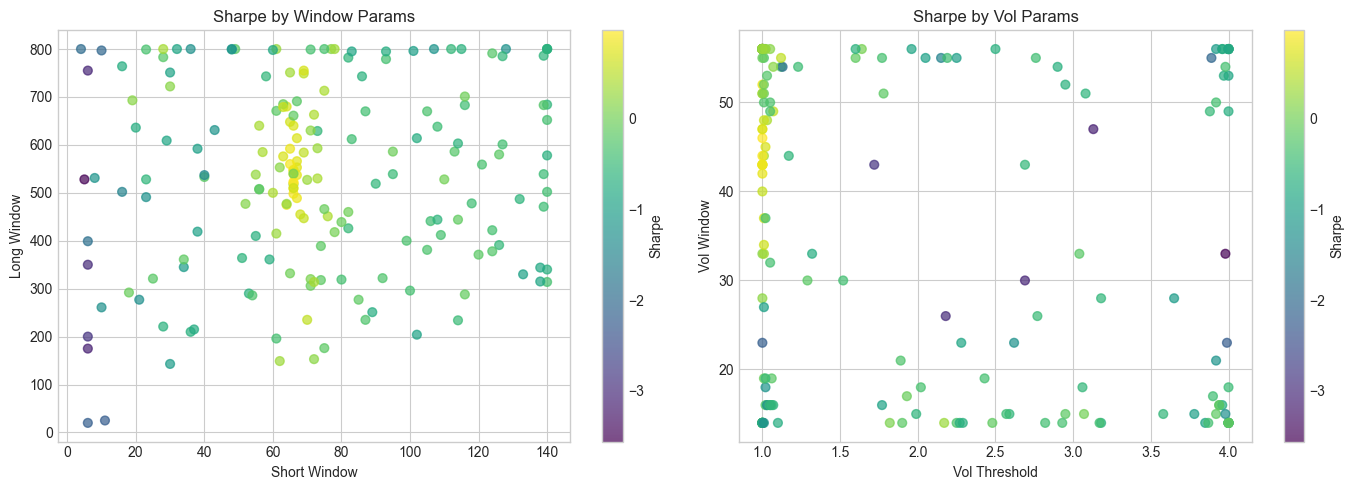

In [9]:
# Optimization landscape
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sc = axes[0].scatter(results_df['sw'], results_df['lw'],
                     c=results_df['sharpe'], cmap='viridis', s=40, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='Sharpe')
axes[0].set_xlabel('Short Window')
axes[0].set_ylabel('Long Window')
axes[0].set_title('Sharpe by Window Params')
 
sc2 = axes[1].scatter(results_df['vt'], results_df['vw'],
                      c=results_df['sharpe'], cmap='viridis', s=40, alpha=0.7)
plt.colorbar(sc2, ax=axes[1], label='Sharpe')
axes[1].set_xlabel('Vol Threshold')
axes[1].set_ylabel('Vol Window')
axes[1].set_title('Sharpe by Vol Params')
 
plt.tight_layout()
plt.show()


--- Momentum (Optimized) ---
Sharpe           0.966
Ann Return       0.269
Ann Vol          0.278
Max Drawdown    -0.236
Calmar           1.142
Skewness         1.782
Kurtosis        22.464
Hit Rate         0.468

--- Momentum (Original Params) ---
Sharpe          0.649
Ann Return      0.341
Ann Vol         0.524
Max Drawdown   -0.484
Calmar          0.703
Skewness        0.244
Kurtosis        6.558
Hit Rate        0.486


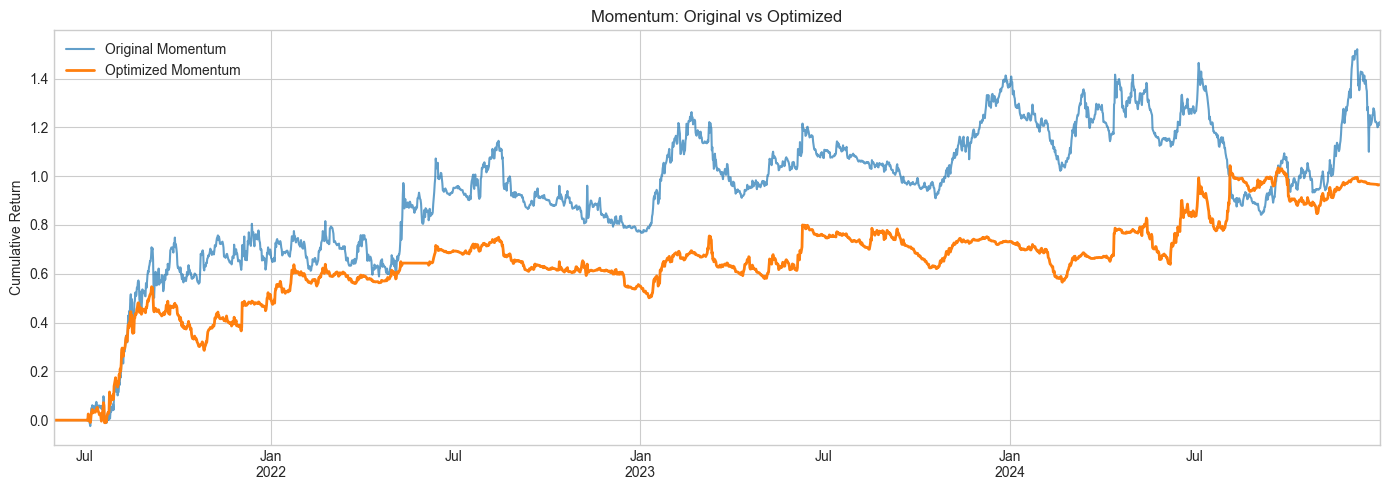

In [10]:
# Generate momentum returns with optimized params
best_sw, best_lw, best_vt, best_vw = res.x
mom_ret_opt = momentum_v2(ret, best_sw, best_lw, best_vt, vol_window=best_vw)
 
# Compare to original
mom_ret_orig = momentum_v2(ret, 69, 287, 2, vol_window=28, exec_lag=2)  # Original params + lag
 
full_report(mom_ret_opt, 'Momentum (Optimized)')
full_report(mom_ret_orig, 'Momentum (Original Params)')
 
fig, ax = plt.subplots(figsize=(14, 5))
mom_ret_orig.cumsum().plot(ax=ax, label='Original Momentum', alpha=0.7)
mom_ret_opt.cumsum().plot(ax=ax, label='Optimized Momentum', linewidth=2)
ax.set_title('Momentum: Original vs Optimized')
ax.set_ylabel('Cumulative Return')
ax.legend()
plt.tight_layout()
plt.show()

# 5. Strategy Combination with Risk Overlays

In [11]:
strats = pd.concat([mr_ret_opt, mom_ret_opt], axis=1).fillna(0)
strats.columns = ['Mean Reversion', 'Momentum']
 
print('Individual Strategy Stats')
print(get_stats_multi(strats).round(3))
print(f'\nCorrelation: {strats.corr().iloc[0,1]:.3f}')

Individual Strategy Stats
                Sharpe  Ann Ret  Ann Vol
Mean Reversion   1.648    1.136    0.689
Momentum         0.966    0.269    0.278

Correlation: -0.241


In [12]:
# WEIGHTING METHODS
 
def optimal_weights(sigma, mu):
    wgt = np.linalg.inv(sigma) @ mu
    return wgt / np.abs(wgt).sum()
 
def eqvol_weights(sigma):
    wgt = 1 / np.sqrt(np.diag(sigma))
    return wgt / np.abs(wgt).sum()
 
def sr_weights(sigma, mu):
    wgt = mu / np.diag(sigma)
    return wgt / np.abs(wgt).sum()
 
# Expanding-window weights (reduces lookahead bias)
min_window = 365  # Minimum 6 months of data before computing weights
 
def expanding_combo(strats_df, min_window=365):
    # Compute portfolio returns using expanding-window optimal weights
    combo = pd.Series(0.0, index=strats_df.index)
    weight_hist = []
    
    for t in range(min_window, len(strats_df)):
        window = strats_df.iloc[:t]
        sigma = window.cov()
        mu = window.mean()
        
        # Regularized optimal weights (shrink covariance toward diagonal)
        shrink = 0.3
        sigma_reg = (1 - shrink) * sigma + shrink * np.diag(np.diag(sigma))
        
        try:
            w = optimal_weights(sigma_reg, mu)
        except np.linalg.LinAlgError:
            w = eqvol_weights(sigma)
        
        # Clamp weights to avoid extreme tilts
        w = np.clip(w, -0.8, 0.8)
        w = w / np.abs(w).sum()
        
        combo.iloc[t] = (strats_df.iloc[t] * w).sum()
        weight_hist.append(w)
    
    return combo.iloc[min_window:], pd.DataFrame(weight_hist, columns=strats_df.columns)
 
combo_expanding, weight_history = expanding_combo(strats)
 
# Also compute fixed-weight combos for comparison
sigma_full = strats.cov()
mu_full = strats.mean()
 
w_opt   = optimal_weights(sigma_full, mu_full)
w_eqvol = eqvol_weights(sigma_full)
w_sr    = sr_weights(sigma_full, mu_full)
 
combo_opt   = (strats * w_opt).sum(1)
combo_eqvol = (strats * w_eqvol).sum(1)
combo_sr    = (strats * w_sr).sum(1)
 
combos = pd.DataFrame({
    'Optimal (fixed)':    combo_opt,
    'EqVol (fixed)':      combo_eqvol,
    'SR-weighted (fixed)': combo_sr,
})
combos['Expanding Optimal'] = combo_expanding
 
print('Combination Method Sharpes')
print((combos.mean() / combos.std() * np.sqrt(FREQ)).round(3))
 
print(f'\nFixed optimal weights: MR={w_opt[0]:.2f}, Mom={w_opt[1]:.2f}')
print(f'Weight history — final: MR={weight_history.iloc[-1,0]:.2f}, Mom={weight_history.iloc[-1,1]:.2f}')

Combination Method Sharpes
Optimal (fixed)        2.166
EqVol (fixed)          2.122
SR-weighted (fixed)    2.150
Expanding Optimal      2.031
dtype: float64

Fixed optimal weights: MR=0.36, Mom=0.64
Weight history — final: MR=0.37, Mom=0.63


In [13]:
# Pick best combo method and apply risk overlays
 
# Use the method with best Sharpe
combo_sharpes = combos.mean() / combos.std() * np.sqrt(FREQ)
best_method = combo_sharpes.idxmax()
print(f'Best combination method: {best_method} (SR={combo_sharpes[best_method]:.3f})')
 
raw_combo = combos[best_method].fillna(0)
 
# VOL TARGETING: scale to ~15% annualized vol
target_vol = 0.15 / np.sqrt(FREQ)  # Per-period target vol
realized_vol = raw_combo.ewm(span=60).std()
vol_scalar = (target_vol / realized_vol.replace(0, np.nan)).clip(0.2, 3.0).shift(1).fillna(1.0)
combo_voltarget = raw_combo * vol_scalar
 
# DRAWDOWN DELEVERAGING: reduce by 50% when DD > 10%
def drawdown_deleverage(returns, dd_threshold=-0.10, deleverage_factor=0.5):
    equity = (1 + returns).cumprod()
    running_max = equity.cummax()
    dd = equity / running_max - 1
    # When in drawdown beyond threshold, reduce next period's exposure
    dd_scalar = np.where(dd.shift(1) < dd_threshold, deleverage_factor, 1.0)
    return returns * dd_scalar
 
combo_final = drawdown_deleverage(combo_voltarget, dd_threshold=-0.10, deleverage_factor=0.5)
combo_final = pd.Series(combo_final, index=raw_combo.index)

Best combination method: Optimal (fixed) (SR=2.166)


# 6. Final Results

In [14]:
# COMPREHENSIVE PERFORMANCE COMPARISON
 
all_strats = pd.DataFrame({
    'Mean Reversion': mr_ret_opt,
    'Momentum': mom_ret_opt,
    'Raw Combo': raw_combo,
    'Vol-Targeted + DD Mgmt': combo_final,
}).fillna(0)
 
print('FULL PERFORMANCE REPORT')
for col in all_strats.columns:
    full_report(all_strats[col], col)
 
print('\n' + '=' * 60)
print(get_stats_multi(all_strats).round(3))

FULL PERFORMANCE REPORT

--- Mean Reversion ---
Sharpe           1.648
Ann Return       1.136
Ann Vol          0.689
Max Drawdown    -0.718
Calmar           1.583
Skewness        -0.645
Kurtosis        13.296
Hit Rate         0.291

--- Momentum ---
Sharpe           0.966
Ann Return       0.269
Ann Vol          0.278
Max Drawdown    -0.236
Calmar           1.142
Skewness         1.782
Kurtosis        22.464
Hit Rate         0.468

--- Raw Combo ---
Sharpe           2.166
Ann Return       0.579
Ann Vol          0.267
Max Drawdown    -0.284
Calmar           2.042
Skewness         0.437
Kurtosis        12.559
Hit Rate         0.502

--- Vol-Targeted + DD Mgmt ---
Sharpe           2.069
Ann Return       0.311
Ann Vol          0.151
Max Drawdown    -0.204
Calmar           1.529
Skewness        -0.461
Kurtosis        22.376
Hit Rate         0.502

                        Sharpe  Ann Ret  Ann Vol
Mean Reversion           1.648    1.136    0.689
Momentum                 0.966    0.269    0.278

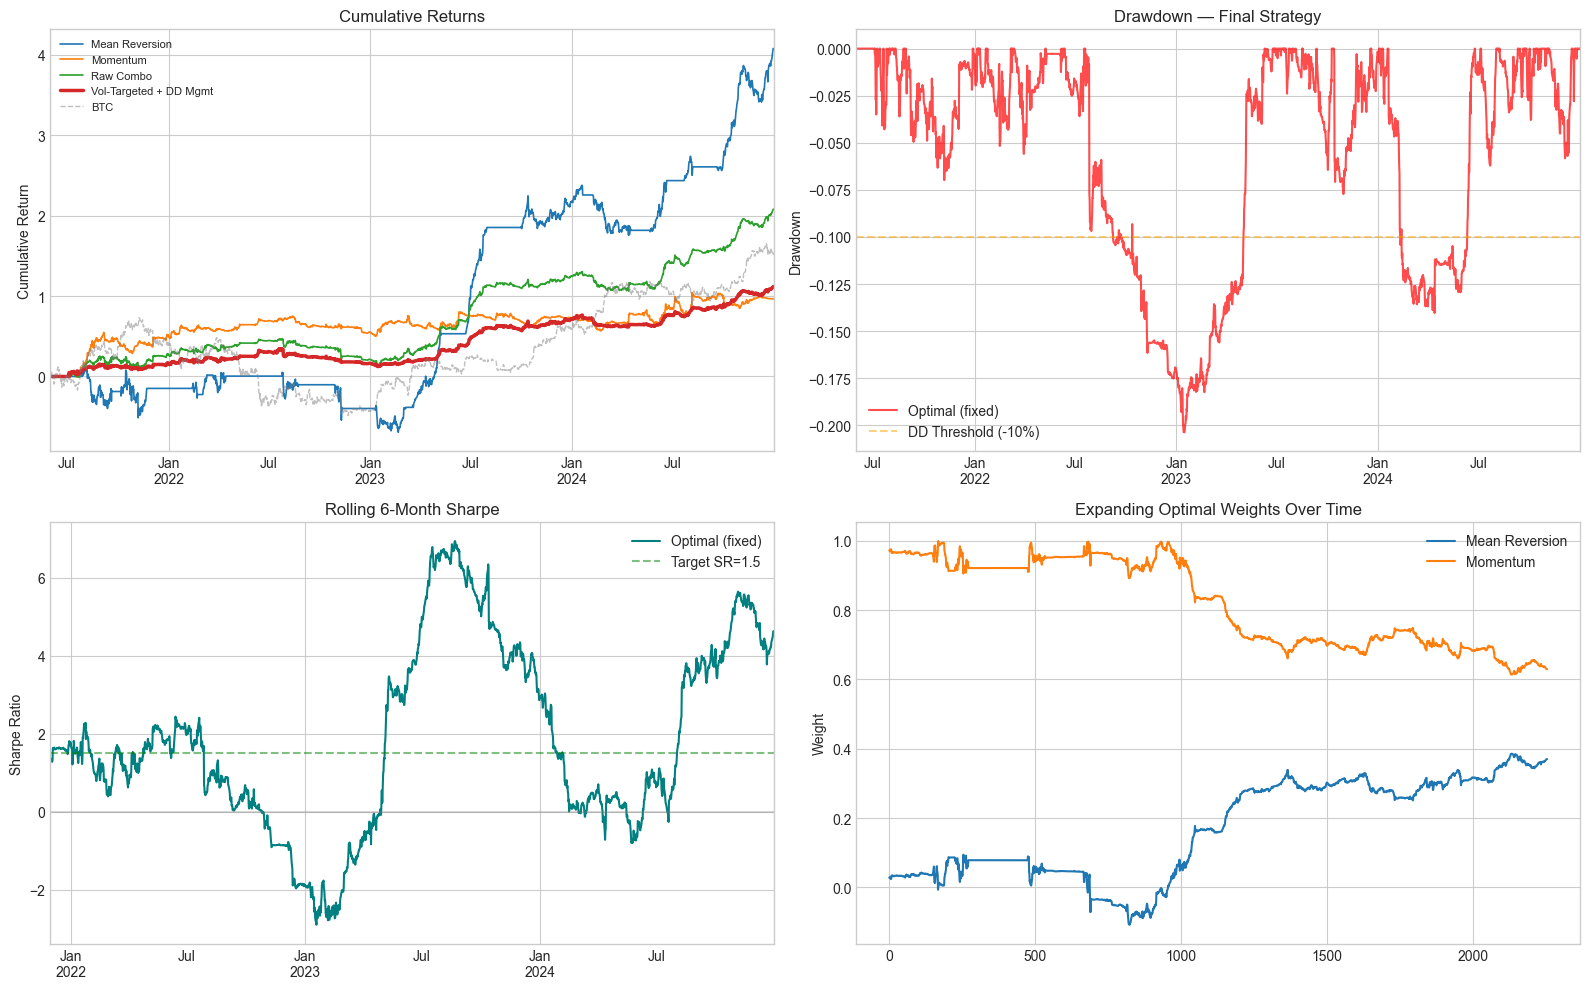

In [15]:
# CUMULATIVE RETURN PLOT
 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
 
# Panel 1: All strategies cumulative
ax = axes[0, 0]
for col in all_strats.columns:
    lw = 2.5 if 'DD' in col else 1.2
    all_strats[col].cumsum().plot(ax=ax, linewidth=lw, label=col)
btc_ret.reindex(all_strats.index).fillna(0).cumsum().plot(
    ax=ax, linewidth=1, color='grey', alpha=0.5, linestyle='--', label='BTC')
ax.set_title('Cumulative Returns')
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=8)
 
# Panel 2: Drawdown
ax = axes[0, 1]
equity = (1 + combo_final).cumprod()
dd = equity / equity.cummax() - 1
dd.plot(ax=ax, color='red', alpha=0.7)
ax.axhline(-0.10, color='orange', linestyle='--', alpha=0.5, label='DD Threshold (-10%)')
ax.set_title('Drawdown — Final Strategy')
ax.set_ylabel('Drawdown')
ax.legend()
 
# Panel 3: Rolling Sharpe
ax = axes[1, 0]
rs = rolling_sharpe(combo_final, window=365)
rs.plot(ax=ax, color='teal')
ax.axhline(1.5, color='green', linestyle='--', alpha=0.5, label='Target SR=1.5')
ax.axhline(0, color='grey', linestyle='-', alpha=0.3)
ax.set_title('Rolling 6-Month Sharpe')
ax.set_ylabel('Sharpe Ratio')
ax.legend()
 
# Panel 4: Weight evolution (if expanding)
ax = axes[1, 1]
if len(weight_history) > 0:
    weight_history.plot(ax=ax)
    ax.set_title('Expanding Optimal Weights Over Time')
    ax.set_ylabel('Weight')
else:
    ax.text(0.5, 0.5, f'Fixed weights: MR={w_opt[0]:.2f}, Mom={w_opt[1]:.2f}',
            transform=ax.transAxes, ha='center', fontsize=14)
    ax.set_title('Portfolio Weights')
 
plt.tight_layout()
plt.show()

In [16]:
# FINAL STATISTICS
 
combo_ret = combo_final
 
stats = {}
stats['Sharpe']          = combo_ret.mean() / combo_ret.std() * np.sqrt(FREQ)
stats['Annual Return']   = combo_ret.mean() * FREQ
stats['Annual Vol']      = combo_ret.std() * np.sqrt(FREQ)
stats['Max Drawdown']    = max_drawdown(combo_ret)
stats['Calmar']          = stats['Annual Return'] / abs(stats['Max Drawdown'])
 
# Alpha / IR vs BTC
df = pd.concat([combo_ret, btc_ret], axis=1).dropna()
df.columns = ['combo', 'btc']
X = sm.add_constant(df['btc'])
Y = df['combo']
ols_res = sm.OLS(Y, X).fit()
 
alpha = ols_res.params['const']
stats['Alpha (ann)']     = alpha * FREQ
stats['Beta']            = ols_res.params['btc']
stats['IR']              = (alpha * FREQ) / (ols_res.resid.std() * np.sqrt(FREQ))
 
stats_s = pd.Series(stats).round(3)
print('FINAL OPTIMIZED STRATEGY STATISTICS')
print(stats_s.to_string())

FINAL OPTIMIZED STRATEGY STATISTICS
Sharpe           2.069
Annual Return    0.311
Annual Vol       0.151
Max Drawdown    -0.204
Calmar           1.529
Alpha (ann)      0.340
Beta            -0.066
IR               2.330


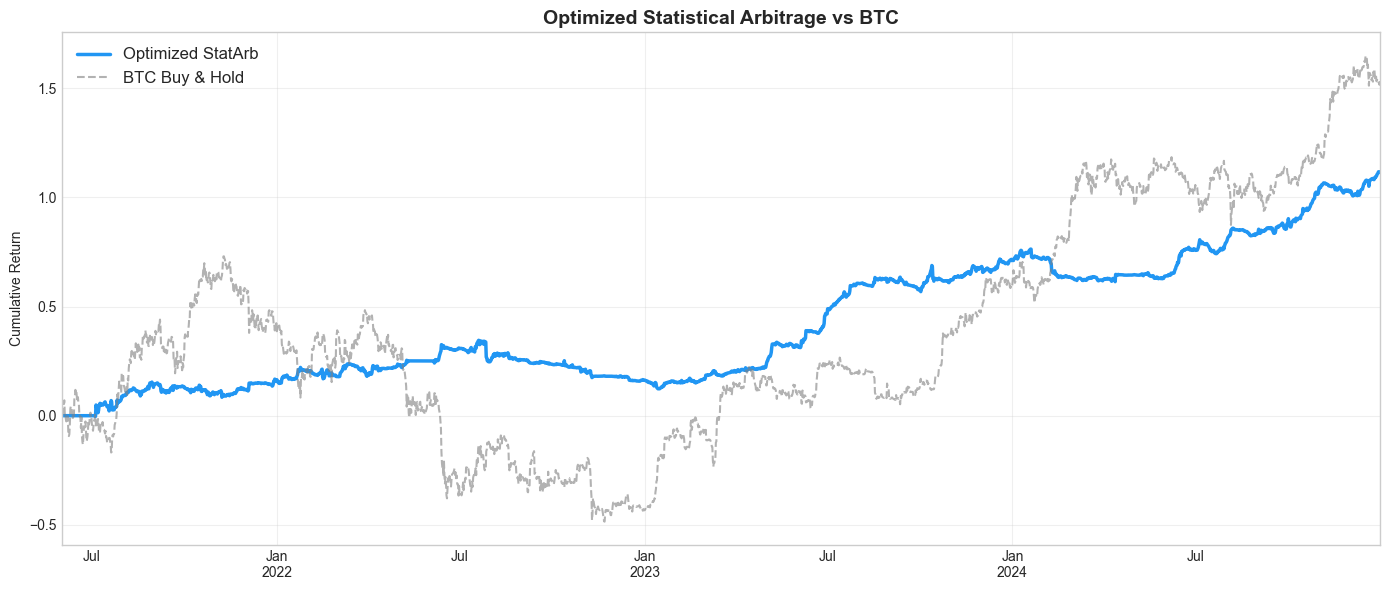


Strategy Sharpe: 2.07
Strategy Max DD: -20.4%
BTC Sharpe:      0.75


In [17]:
fig, ax = plt.subplots(figsize=(14, 6))
combo_ret.cumsum().plot(ax=ax, linewidth=2.5, label='Optimized StatArb', color='#2196F3')
btc_ret.reindex(combo_ret.index).fillna(0).cumsum().plot(
    ax=ax, linewidth=1.5, label='BTC Buy & Hold', color='grey', alpha=0.6, linestyle='--')
ax.set_title('Optimized Statistical Arbitrage vs BTC', fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
print(f'\nStrategy Sharpe: {stats_s["Sharpe"]:.2f}')
print(f'Strategy Max DD: {stats_s["Max Drawdown"]:.1%}')
print(f'BTC Sharpe:      {(btc_ret.mean()/btc_ret.std()*np.sqrt(FREQ)):.2f}')

# 7. Testing Set Performance

In [18]:
# TEST SET: Prepare returns

ret_test = px_test.pct_change().fillna(0)

btc_px_test  = px_test['BTCUSDT']
btc_ret_test = btc_px_test.pct_change()
ret_test = ret_test.drop(columns=['BTCUSDT'], errors='ignore')

# Use same liquid coins from training
ret_test = ret_test[ret_test.columns.intersection(ret.columns)]
print(f'Test period: {px_test.index[0].date()} to {px_test.index[-1].date()}')
print(f'Test coins: {len(ret_test.columns)}')

Test period: 2025-01-01 to 2026-03-25
Test coins: 139


In [19]:
# TEST SET: Run strategies with FROZEN parameters

# Mean reversion — use best_params from training grid search
mr_ret_test = mean_reversion_v3(px_test, ret_test, btc_px_test, **best_params)

# Momentum — use best params from training Bayesian opt
mom_ret_test = momentum_v2(ret_test, best_sw, best_lw, best_vt, vol_window=best_vw)

# Combine with FIXED weights from training (no re-optimization)
strats_test = pd.concat([mr_ret_test, mom_ret_test], axis=1).fillna(0)
strats_test.columns = ['Mean Reversion', 'Momentum']

# Use the same weighting method that won in-sample
if best_method == 'Expanding Optimal':
    # Use final training weights (frozen)
    w_final = weight_history.iloc[-1].values
else:
    w_final = w_opt  # fallback to fixed optimal

raw_combo_test = (strats_test * w_final).sum(axis=1)

# Apply same vol targeting + DD management
target_vol_per = 0.15 / np.sqrt(FREQ)
realized_vol_test = raw_combo_test.ewm(span=60).std()
vol_scalar_test = (target_vol_per / realized_vol_test.replace(0, np.nan)).clip(0.2, 3.0).shift(1).fillna(1.0)
combo_vt_test = raw_combo_test * vol_scalar_test

combo_test_final = drawdown_deleverage(combo_vt_test, dd_threshold=-0.10, deleverage_factor=0.5)
combo_test_final = pd.Series(combo_test_final, index=raw_combo_test.index)

print('=== OUT-OF-SAMPLE RESULTS ===')
full_report(mr_ret_test, 'MR (OOS)')
full_report(mom_ret_test, 'Momentum (OOS)')
full_report(combo_test_final, 'Combined (OOS)')

=== OUT-OF-SAMPLE RESULTS ===

--- MR (OOS) ---
Sharpe           5.981
Ann Return       6.811
Ann Vol          1.139
Max Drawdown    -0.344
Calmar          19.790
Skewness         5.708
Kurtosis        57.436
Hit Rate         0.261

--- Momentum (OOS) ---
Sharpe          -2.900
Ann Return      -0.911
Ann Vol          0.314
Max Drawdown    -0.712
Calmar          -1.279
Skewness        -1.395
Kurtosis        14.266
Hit Rate         0.401

--- Combined (OOS) ---
Sharpe           2.896
Ann Return       0.502
Ann Vol          0.173
Max Drawdown    -0.141
Calmar           3.550
Skewness         2.400
Kurtosis        31.047
Hit Rate         0.487


Sharpe           2.896
Ann Return       0.502
Ann Vol          0.173
Max Drawdown    -0.141
Calmar           3.550
Skewness         2.400
Kurtosis        31.047
Hit Rate         0.487
Name: Combined (OOS), dtype: float64

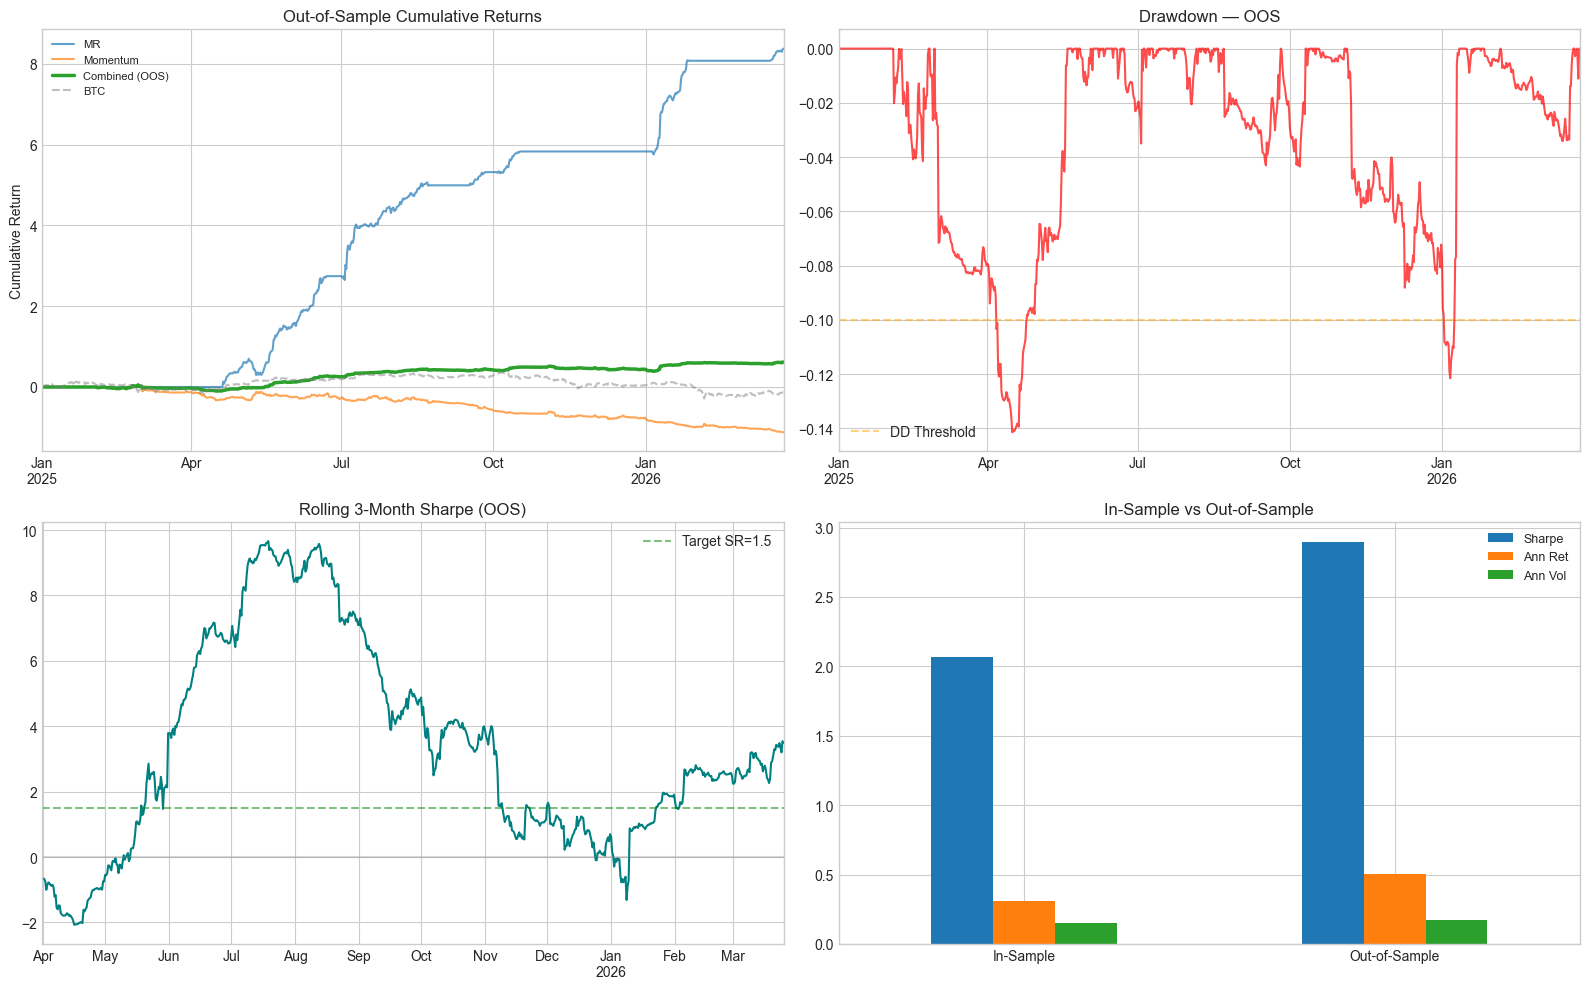

IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON
               In-Sample    OOS
Alpha (ann)        0.340    NaN
Annual Return      0.311  0.502
Annual Vol         0.151  0.173
Beta              -0.066    NaN
Calmar             1.529  3.550
IR                 2.330    NaN
Max Drawdown      -0.204 -0.141
Sharpe             2.069  2.896


In [21]:
# TEST SET: Diagnostics

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Cumulative returns
ax = axes[0, 0]
mr_ret_test.cumsum().plot(ax=ax, label='MR', alpha=0.7)
mom_ret_test.cumsum().plot(ax=ax, label='Momentum', alpha=0.7)
combo_test_final.cumsum().plot(ax=ax, linewidth=2.5, label='Combined (OOS)')
btc_ret_test.reindex(combo_test_final.index).fillna(0).cumsum().plot(
    ax=ax, color='grey', linestyle='--', alpha=0.5, label='BTC')
ax.set_title('Out-of-Sample Cumulative Returns')
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=8)

# Drawdown
ax = axes[0, 1]
eq_test = (1 + combo_test_final).cumprod()
dd_test = eq_test / eq_test.cummax() - 1
dd_test.plot(ax=ax, color='red', alpha=0.7)
ax.axhline(-0.10, color='orange', linestyle='--', alpha=0.5, label='DD Threshold')
ax.set_title('Drawdown — OOS')
ax.legend()

# Rolling Sharpe
ax = axes[1, 0]
rs_test = rolling_sharpe(combo_test_final, window=180)
rs_test.plot(ax=ax, color='teal')
ax.axhline(1.5, color='green', linestyle='--', alpha=0.5, label='Target SR=1.5')
ax.axhline(0, color='grey', linestyle='-', alpha=0.3)
ax.set_title('Rolling 3-Month Sharpe (OOS)')
ax.legend()

# In-sample vs OOS comparison
ax = axes[1, 1]
compare = pd.DataFrame({
    'In-Sample': get_stats(combo_final),
    'Out-of-Sample': get_stats(combo_test_final),
})
compare.T.plot(kind='bar', ax=ax, rot=0)
ax.set_title('In-Sample vs Out-of-Sample')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
print('IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON')

oos_stats = {}
oos_stats['Sharpe']        = combo_test_final.mean() / combo_test_final.std() * np.sqrt(FREQ)
oos_stats['Annual Return'] = combo_test_final.mean() * FREQ
oos_stats['Annual Vol']    = combo_test_final.std() * np.sqrt(FREQ)
oos_stats['Max Drawdown']  = max_drawdown(combo_test_final)
oos_stats['Calmar']        = oos_stats['Annual Return'] / abs(oos_stats['Max Drawdown'])

df_compare = pd.DataFrame({'In-Sample': stats_s, 'OOS': pd.Series(oos_stats)}).round(3)
print(df_compare.to_string())